# Baseline and tuning training audit

This notebook discovers classification and reconstruction logs dynamically. Completion is determined from the latest job block in each append-only log. Only a matching training finish marker with `rc=0` is included in performance summaries.

The same scanner also recognizes future `trial_000` style tuning directories. Failed, incomplete, and archived attempts remain visible in status tables but are excluded from model comparisons.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RESULTS_ROOT = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC")
ACTIVE_TASKS = {"classification", "reconstruction"}
INCLUDE_ARCHIVED_IN_PERFORMANCE = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 120})

if not RESULTS_ROOT.is_dir():
    raise FileNotFoundError(RESULTS_ROOT)

RESULTS_ROOT

PosixPath('/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC')

## Log parser

Logs are written with append mode, so an old successful marker is not sufficient. The parser finds the final `HOST` line and evaluates only the job block that follows it.

In [2]:
HOST_RE = re.compile(r"^--- HOST:\s+JOB=(\d*)")
CONFIG_RE = re.compile(r"^--- CONFIG:\s*(.+?)\s*$")
FINISH_RE = re.compile(
    r"^--- (train_classification|train_reconstruction|run_inference|train_geometry_selection) "
    r"finished \(rc=(-?\d+)\)\s*$"
)
TRIAL_RE = re.compile(r"(?:^|[_-])trial[_-]?(\d+)(?:$|[_-])", re.IGNORECASE)
ROUTE_CLASS_RE = re.compile(r"^class(\d+)$", re.IGNORECASE)
TARGET_RE = re.compile(r"(?:^|_)(energy|zenith|azimuth)(?:_|\.|$)", re.IGNORECASE)
ARCHIVE_TOKENS = ("failed", "cancelled", "archive", "archived", "_old", "oom")

EXPECTED_STAGE = {
    "classification": "train_classification",
    "reconstruction": "train_reconstruction",
}


def _trial_number(parts):
    for part in parts:
        match = TRIAL_RE.search(part)
        if match:
            return int(match.group(1))
    return None


def _target_from_path(path):
    for value in (path.parent.name, path.name):
        match = TARGET_RE.search(value)
        if match:
            return match.group(1).lower()
    return None


def path_metadata(log_path):
    relative = log_path.relative_to(RESULTS_ROOT)
    parts = relative.parts
    task_positions = [i for i, part in enumerate(parts) if part in ACTIVE_TASKS]
    if not task_positions:
        return None

    task_index = task_positions[0]
    task = parts[task_index]
    geometry = parts[task_index - 1] if task_index else None
    category = parts[task_index + 1] if len(parts) > task_index + 1 else None

    route_class = None
    for part in parts[task_index + 2:]:
        match = ROUTE_CLASS_RE.match(part)
        if match:
            route_class = int(match.group(1))
            break

    lower_parts = [part.lower() for part in parts]
    archived = any(token in part for part in lower_parts for token in ARCHIVE_TOKENS)
    trial_number = _trial_number(parts)
    if "baseline" in lower_parts:
        experiment = "baseline"
    elif trial_number is not None:
        experiment = "tuning"
    else:
        experiment = "other"

    return {
        "geometry": geometry,
        "task": task,
        "category": category,
        "route_class": route_class,
        "target": _target_from_path(log_path) if task == "reconstruction" else "classification",
        "experiment": experiment,
        "trial_number": trial_number,
        "archived": archived,
        "relative_log_path": str(relative),
        "log_path": str(log_path),
    }


def parse_latest_attempt(log_path):
    text = log_path.read_text(errors="replace")
    lines = text.splitlines()
    host_positions = [i for i, line in enumerate(lines) if HOST_RE.match(line)]
    block_start = host_positions[-1] if host_positions else 0
    block = lines[block_start:]

    host_match = HOST_RE.match(block[0]) if block else None
    job_id = host_match.group(1) if host_match and host_match.group(1) else None
    config_path = None
    finish_matches = []
    for line in block:
        config_match = CONFIG_RE.match(line)
        if config_match:
            config_path = config_match.group(1)
        finish_match = FINISH_RE.match(line)
        if finish_match:
            finish_matches.append(finish_match)

    if not finish_matches:
        return {
            "job_id": job_id,
            "config_path": config_path,
            "finish_stage": None,
            "return_code": None,
            "status": "INCOMPLETE",
        }

    finish_match = finish_matches[-1]
    stage = finish_match.group(1)
    return_code = int(finish_match.group(2))
    status = "COMPLETE" if return_code == 0 else "FAILED"
    return {
        "job_id": job_id,
        "config_path": config_path,
        "finish_stage": stage,
        "return_code": return_code,
        "status": status,
    }


def scan_training_logs(root=RESULTS_ROOT):
    rows = []
    for log_path in sorted(root.rglob("*.out")):
        metadata = path_metadata(log_path)
        if metadata is None:
            continue
        attempt = parse_latest_attempt(log_path)
        expected = EXPECTED_STAGE[metadata["task"]]
        stage_matches = attempt["finish_stage"] in (None, expected)
        if not stage_matches:
            attempt["status"] = "INCONSISTENT"
        rows.append({**metadata, **attempt, "stage_matches_task": stage_matches})

    columns = [
        "geometry", "task", "category", "route_class", "target",
        "experiment", "trial_number", "archived", "job_id", "status",
        "return_code", "finish_stage", "stage_matches_task", "config_path",
        "relative_log_path", "log_path",
    ]
    return pd.DataFrame(rows, columns=columns)


## Dynamic status dashboard

Run this section again at any time to discover newly completed jobs or tuning trials. Archived attempts are shown separately.

In [3]:
jobs = scan_training_logs()

status_order = ["COMPLETE", "INCOMPLETE", "FAILED", "INCONSISTENT"]
jobs["status"] = pd.Categorical(jobs["status"], categories=status_order, ordered=True)
jobs = jobs.sort_values(
    ["archived", "geometry", "task", "category", "route_class", "target", "trial_number"],
    na_position="last",
).reset_index(drop=True)

print(f"Discovered {len(jobs):,} training logs under {RESULTS_ROOT}")
display(
    jobs.groupby(["archived", "geometry", "task", "status"], observed=True)
    .size()
    .rename("n_logs")
    .reset_index()
)

active_jobs = jobs.loc[~jobs["archived"]].copy()
problem_jobs = active_jobs.loc[active_jobs["status"] != "COMPLETE", [
    "geometry", "task", "category", "route_class", "target",
    "experiment", "trial_number", "job_id", "status", "return_code", "relative_log_path",
]]

print("Active jobs that are not complete:")
display(problem_jobs.reset_index(drop=True))

archived_jobs = jobs.loc[jobs["archived"], [
    "geometry", "task", "category", "route_class", "target",
    "job_id", "status", "return_code", "relative_log_path",
]]
print("Archived attempts, excluded from performance summaries:")
display(archived_jobs.reset_index(drop=True))

Discovered 61 training logs under /project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC


,archived,geometry,task,status,n_logs
0,False,102_string_emax1e6,classification,COMPLETE,3
1,False,102_string_emax1e6,reconstruction,COMPLETE,21
2,False,160_string_emax1e6,classification,COMPLETE,3
3,False,160_string_emax1e6,reconstruction,COMPLETE,25
4,False,160_string_emax1e6,reconstruction,INCOMPLETE,6
5,False,160_string_emax1e6,reconstruction,FAILED,1
6,True,102_string_emax1e6,reconstruction,INCOMPLETE,1
7,True,160_string_emax1e6,reconstruction,INCOMPLETE,1


Active jobs that are not complete:


,geometry,task,category,route_class,target,experiment,trial_number,job_id,status,return_code,relative_log_path
0,160_string_emax1e6,reconstruction,category1_isMuonCC,0.0,energy,tuning,1.0,48766679,INCOMPLETE,NaN,hyperparameter_tuning/160_string_emax1e6/reconstruction/category1_isMuonCC/energy/pilot_v1/model_outputs/340StringMC...
1,160_string_emax1e6,reconstruction,category1_isMuonCC,1.0,energy,tuning,1.0,48766680,FAILED,1.0,hyperparameter_tuning/160_string_emax1e6/reconstruction/category1_isMuonCC/energy/pilot_v1/model_outputs/340StringMC...
2,160_string_emax1e6,reconstruction,category1_isMuonCC,NaN,None,tuning,0.0,None,INCOMPLETE,NaN,hyperparameter_tuning/160_string_emax1e6/reconstruction/category1_isMuonCC/energy/pilot_v1/trials/trial_0000/submiss...
3,160_string_emax1e6,reconstruction,category1_isMuonCC,NaN,None,tuning,1.0,None,INCOMPLETE,NaN,hyperparameter_tuning/160_string_emax1e6/reconstruction/category1_isMuonCC/energy/pilot_v1/trials/trial_0001/submiss...
4,160_string_emax1e6,reconstruction,category1_isMuonCC,NaN,None,tuning,2.0,None,INCOMPLETE,NaN,hyperparameter_tuning/160_string_emax1e6/reconstruction/category1_isMuonCC/energy/pilot_v1/trials/trial_0002/submiss...
5,160_string_emax1e6,reconstruction,category1_isMuonCC,NaN,None,other,NaN,48777269,INCOMPLETE,NaN,hyperparameter_tuning/160_string_emax1e6/reconstruction/category1_isMuonCC/energy/pilot_v1/controller_48777269_stopp...
6,160_string_emax1e6,reconstruction,category1_isMuonCC,NaN,None,other,NaN,48839086,INCOMPLETE,NaN,hyperparameter_tuning/160_string_emax1e6/reconstruction/category1_isMuonCC/energy/pilot_v1/controller_48839086.out


Archived attempts, excluded from performance summaries:


,geometry,task,category,route_class,target,job_id,status,return_code,relative_log_path
0,102_string_emax1e6,reconstruction,category2_tauCC_others_muonCC,2.0,zenith,None,INCOMPLETE,NaN,102_string_emax1e6/reconstruction/category2_tauCC_others_muonCC/class2/baseline/train_and_val/zenith_failed_job48746...
1,160_string_emax1e6,reconstruction,category1_isMuonCC,0.0,azimuth,None,INCOMPLETE,NaN,160_string_emax1e6/reconstruction/category1_isMuonCC/class0/baseline/train_and_val/azimuth_failed_exit127_job4845405...


## Completed training audit

Only active jobs whose latest attempt ended with the expected training stage and `rc=0` enter this section. Artifact checks are additional consistency checks, not completion criteria.

In [4]:
def read_config_integer(config_path, key):
    if not config_path:
        return None
    path = Path(config_path)
    if not path.is_file():
        return None
    match = re.search(rf"^\s*{re.escape(key)}:\s*(\d+)\s*$", path.read_text(), re.MULTILINE)
    return int(match.group(1)) if match else None


def build_completed_audit(job_table):
    selected = job_table.loc[
        (job_table["status"] == "COMPLETE")
        & job_table["stage_matches_task"]
        & (INCLUDE_ARCHIVED_IN_PERFORMANCE | ~job_table["archived"])
    ].copy()

    summary_rows = []
    histories = {}
    for row in selected.itertuples(index=False):
        log_path = Path(row.log_path)
        output_dir = log_path.parent
        history_path = output_dir / "training_history_by_epoch.csv"
        checkpoint_path = output_dir / "best_model.pth"
        metrics_path = output_dir / "validation_metrics_summary.csv"

        history_exists = history_path.is_file()
        checkpoint_exists = checkpoint_path.is_file()
        metrics_exists = metrics_path.is_file()
        artifact_consistent = history_exists and checkpoint_exists and metrics_exists

        result = {
            "geometry": row.geometry,
            "task": row.task,
            "category": row.category,
            "route_class": row.route_class,
            "target": row.target,
            "experiment": row.experiment,
            "trial_number": row.trial_number,
            "job_id": row.job_id,
            "history_exists": history_exists,
            "checkpoint_exists": checkpoint_exists,
            "metrics_exists": metrics_exists,
            "artifact_consistent": artifact_consistent,
            "relative_log_path": row.relative_log_path,
            "log_path": row.log_path,
        }

        if history_exists:
            history = pd.read_csv(history_path)
            history["epoch"] = pd.to_numeric(history["epoch"], errors="coerce")
            history["val_loss"] = pd.to_numeric(history["val_loss"], errors="coerce")
            if "train_loss" in history:
                history["train_loss"] = pd.to_numeric(history["train_loss"], errors="coerce")
            history = history.dropna(subset=["epoch", "val_loss"]).copy()
            histories[row.log_path] = history

            best_index = history["val_loss"].idxmin()
            best_epoch = int(history.loc[best_index, "epoch"])
            last_epoch = int(history["epoch"].iloc[-1])
            max_epochs = read_config_integer(row.config_path, "max_epochs")
            patience = read_config_integer(row.config_path, "early_stopping_patience")

            result.update({
                "epochs_ran": len(history),
                "first_epoch": int(history["epoch"].iloc[0]),
                "last_epoch": last_epoch,
                "best_epoch": best_epoch,
                "best_val_loss": float(history.loc[best_index, "val_loss"]),
                "last_val_loss": float(history["val_loss"].iloc[-1]),
                "best_within_last_two_epochs": best_epoch >= last_epoch - 1,
                "configured_max_epochs": max_epochs,
                "configured_patience": patience,
                "reached_epoch_ceiling": bool(max_epochs is not None and len(history) >= max_epochs),
            })

        summary_rows.append(result)

    summary = pd.DataFrame(summary_rows)
    if not summary.empty:
        summary = summary.sort_values(
            ["geometry", "task", "category", "route_class", "target", "trial_number"],
            na_position="last",
        ).reset_index(drop=True)
    return summary, histories


audit, histories = build_completed_audit(jobs)
print(f"Completed active training logs included in audit: {len(audit):,}")

summary_columns = [
    "geometry", "task", "category", "route_class", "target",
    "experiment", "trial_number", "job_id", "epochs_ran", "best_epoch",
    "best_val_loss", "last_val_loss", "best_within_last_two_epochs",
    "configured_max_epochs", "configured_patience", "reached_epoch_ceiling",
    "artifact_consistent",
]
display(audit.loc[:, [column for column in summary_columns if column in audit]].reset_index(drop=True))

if not audit.empty:
    display(
        audit.groupby(["geometry", "task", "target"], dropna=False)
        .agg(
            n_models=("log_path", "size"),
            n_at_epoch_ceiling=("reached_epoch_ceiling", "sum"),
            n_best_near_end=("best_within_last_two_epochs", "sum"),
            n_artifact_consistent=("artifact_consistent", "sum"),
        )
        .reset_index()
    )

Completed active training logs included in audit: 52


,geometry,task,category,route_class,target,experiment,trial_number,job_id,epochs_ran,best_epoch,best_val_loss,last_val_loss,best_within_last_two_epochs,configured_max_epochs,configured_patience,reached_epoch_ceiling,artifact_consistent
0,102_string_emax1e6,classification,category1_isMuonCC,NaN,classification,baseline,NaN,48746652,30,24,0.338849,0.340689,False,30,5,True,True
1,102_string_emax1e6,classification,category2_tauCC_others_muonCC,NaN,classification,baseline,NaN,48746653,30,28,0.664721,0.664809,True,30,5,True,True
2,102_string_emax1e6,classification,category_3_contains_muon,NaN,classification,baseline,NaN,48746654,30,27,0.231363,0.232698,False,30,5,True,True
3,102_string_emax1e6,reconstruction,category1_isMuonCC,0.0,azimuth,baseline,NaN,48746657,30,29,0.921021,0.921021,True,30,5,True,True
4,102_string_emax1e6,reconstruction,category1_isMuonCC,0.0,energy,baseline,NaN,48746655,30,28,0.042786,0.042969,True,30,5,True,True
5,102_string_emax1e6,reconstruction,category1_isMuonCC,0.0,zenith,baseline,NaN,48746656,30,29,0.100708,0.100708,True,30,5,True,True
6,102_string_emax1e6,reconstruction,category1_isMuonCC,1.0,azimuth,baseline,NaN,48746660,30,29,-0.279085,-0.279085,True,30,5,True,True
7,102_string_emax1e6,reconstruction,category1_isMuonCC,1.0,energy,baseline,NaN,48746658,30,28,0.068978,0.069340,True,30,5,True,True
8,102_string_emax1e6,reconstruction,category1_isMuonCC,1.0,zenith,baseline,NaN,48746659,30,29,-0.779118,-0.779118,True,30,5,True,True
9,102_string_emax1e6,reconstruction,category2_tauCC_others_muonCC,0.0,azimuth,baseline,NaN,48746663,30,29,0.971703,0.971703,True,30,5,True,True


,geometry,task,target,n_models,n_at_epoch_ceiling,n_best_near_end,n_artifact_consistent
0,102_string_emax1e6,classification,classification,3,3,1,3
1,102_string_emax1e6,reconstruction,azimuth,7,6,6,7
2,102_string_emax1e6,reconstruction,energy,7,7,5,7
3,102_string_emax1e6,reconstruction,zenith,7,7,6,7
4,160_string_emax1e6,classification,classification,3,2,1,3
5,160_string_emax1e6,reconstruction,azimuth,7,6,5,7
6,160_string_emax1e6,reconstruction,energy,11,6,3,11
7,160_string_emax1e6,reconstruction,zenith,7,7,7,7


## Validation loss plots

The overview overlays completed models by target. Use the detailed plotting function to inspect a smaller filtered selection with train and validation loss together.

In [5]:
def filter_audit(geometry=None, task=None, category=None, route_class=None, target=None, experiment=None):
    selected = audit.copy()
    filters = {
        "geometry": geometry,
        "task": task,
        "category": category,
        "route_class": route_class,
        "target": target,
        "experiment": experiment,
    }
    for column, value in filters.items():
        if value is not None:
            selected = selected.loc[selected[column] == value]
    return selected.reset_index(drop=True)


def model_label(row):
    class_label = "" if pd.isna(row.route_class) else f" class{int(row.route_class)}"
    trial_label = "" if pd.isna(row.trial_number) else f" trial{int(row.trial_number):03d}"
    return f"{row.category}{class_label}{trial_label}"


def plot_validation_overview(geometry, task="reconstruction", experiment="baseline"):
    selected = filter_audit(geometry=geometry, task=task, experiment=experiment)
    if selected.empty:
        print("No completed models match this selection.")
        return None

    targets = sorted(selected["target"].dropna().unique())
    fig, axes = plt.subplots(1, len(targets), figsize=(6 * len(targets), 4.5), squeeze=False)
    for axis, target in zip(axes.ravel(), targets):
        target_rows = selected.loc[selected["target"] == target]
        for row in target_rows.itertuples(index=False):
            history = histories.get(row.log_path)
            if history is None:
                continue
            axis.plot(history["epoch"], history["val_loss"], linewidth=1.6, label=model_label(row))
        axis.set_title(str(target))
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Validation loss")
        axis.grid(True, alpha=0.25)
        axis.legend(fontsize=7)
    fig.suptitle(f"{geometry}: completed {experiment} {task} models", y=1.03)
    fig.tight_layout()
    plt.show()
    return None


def plot_model_histories(**filters):
    selected = filter_audit(**filters)
    if selected.empty:
        print("No completed models match this selection.")
        return None

    n_models = len(selected)
    n_columns = min(3, n_models)
    n_rows = int(np.ceil(n_models / n_columns))
    fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.2 * n_columns, 3.8 * n_rows), squeeze=False)
    for axis, row in zip(axes.ravel(), selected.itertuples(index=False)):
        history = histories.get(row.log_path)
        if history is not None:
            if "train_loss" in history:
                axis.plot(history["epoch"], history["train_loss"], label="train")
            axis.plot(history["epoch"], history["val_loss"], label="validation")
            axis.axvline(row.best_epoch, color="black", linestyle=":", linewidth=1, label="best epoch")
        axis.set_title(f"{row.geometry} | {model_label(row)} | {row.target}", fontsize=9)
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Loss")
        axis.grid(True, alpha=0.25)
        axis.legend(fontsize=8)
    for axis in axes.ravel()[n_models:]:
        axis.set_visible(False)
    fig.tight_layout()
    plt.show()
    return None

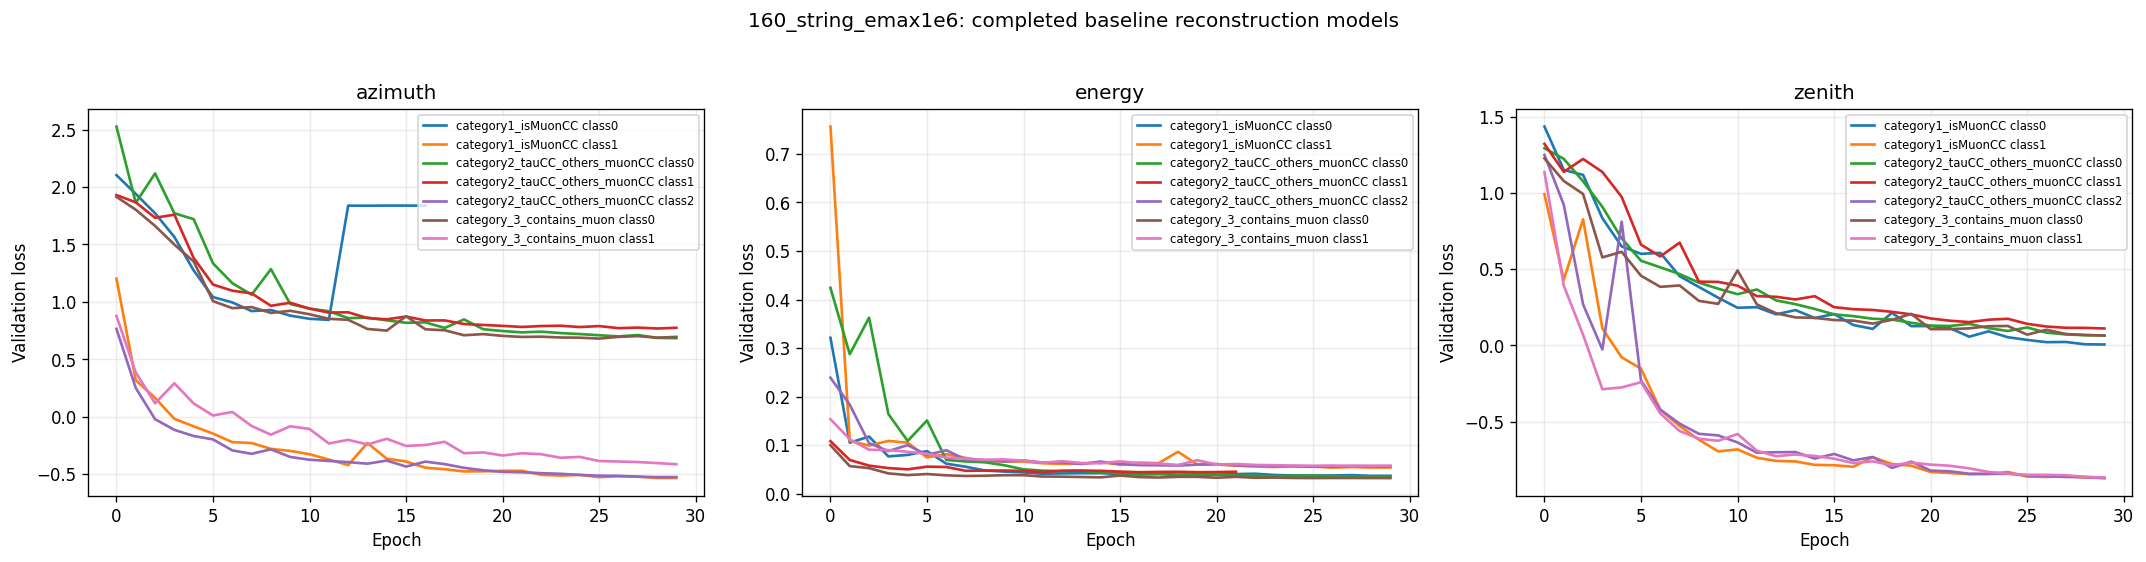

In [6]:
plot_validation_overview(
    geometry="160_string_emax1e6",
    task="reconstruction",
    experiment="baseline",
)

## Example detailed filters

Uncomment and adapt one of these calls after running the cells above.

```python
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="energy")
plot_model_histories(geometry="102_string_emax1e6", task="classification")
plot_model_histories(geometry="160_string_emax1e6", category="category_3_contains_muon")
```

Rerun the status and audit cells after new jobs finish. New trial numbers and completed models will be discovered automatically.

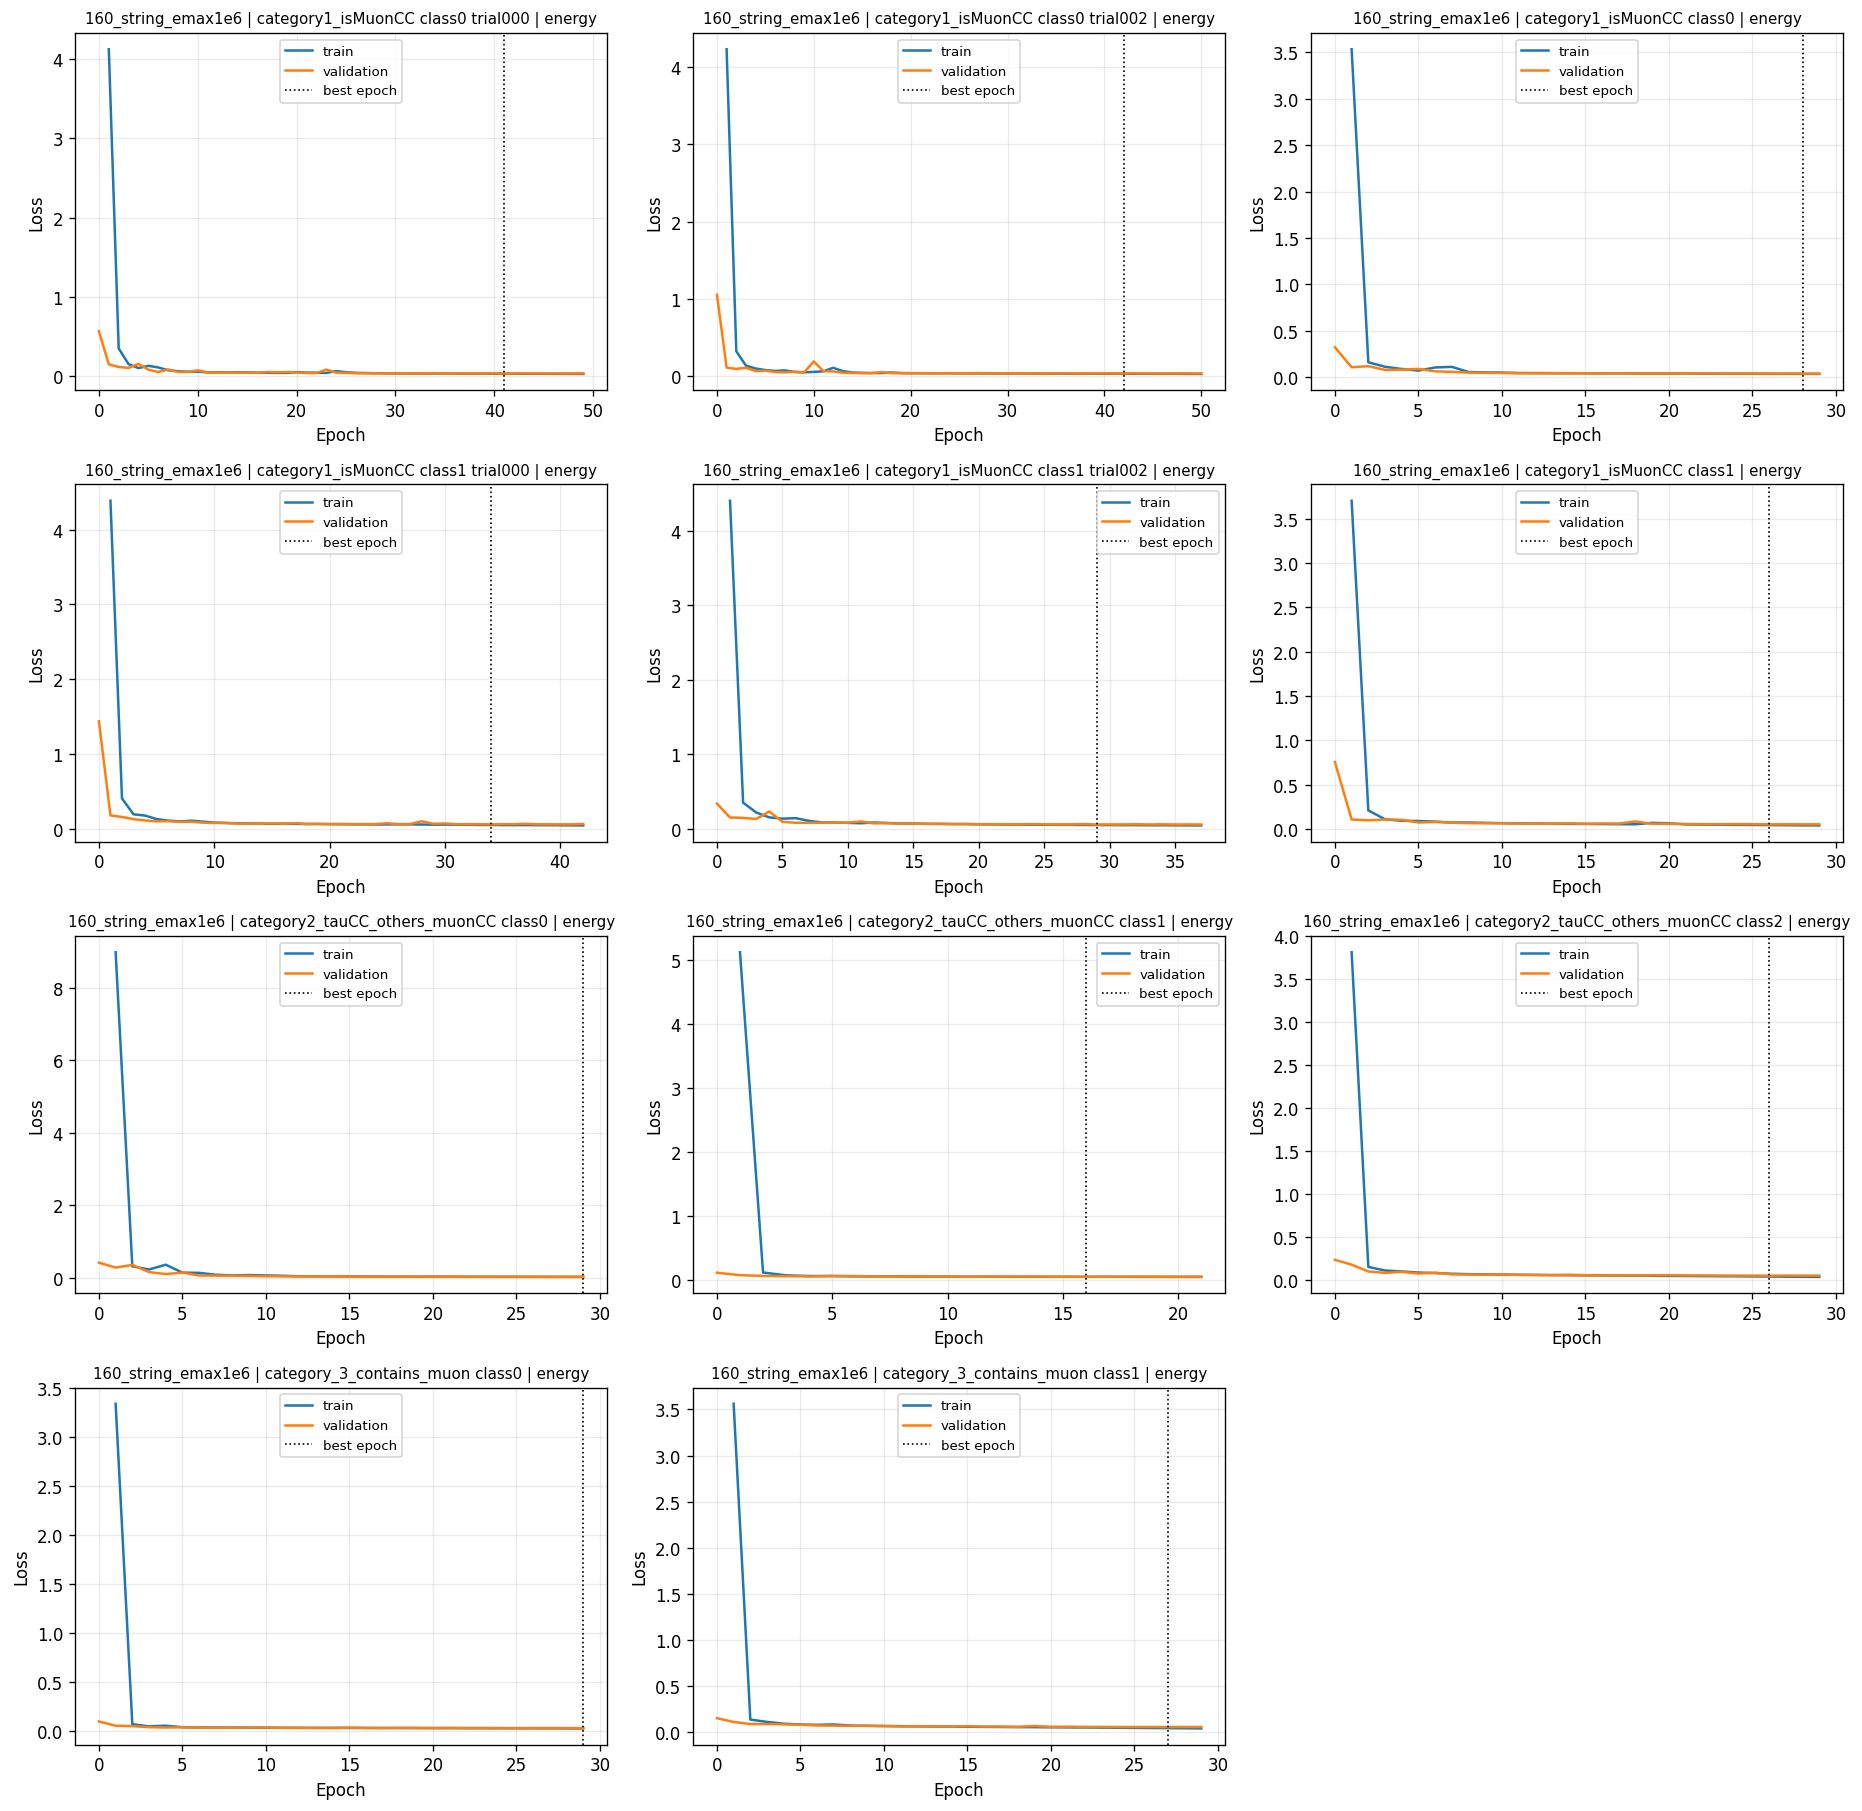

In [7]:
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="energy")


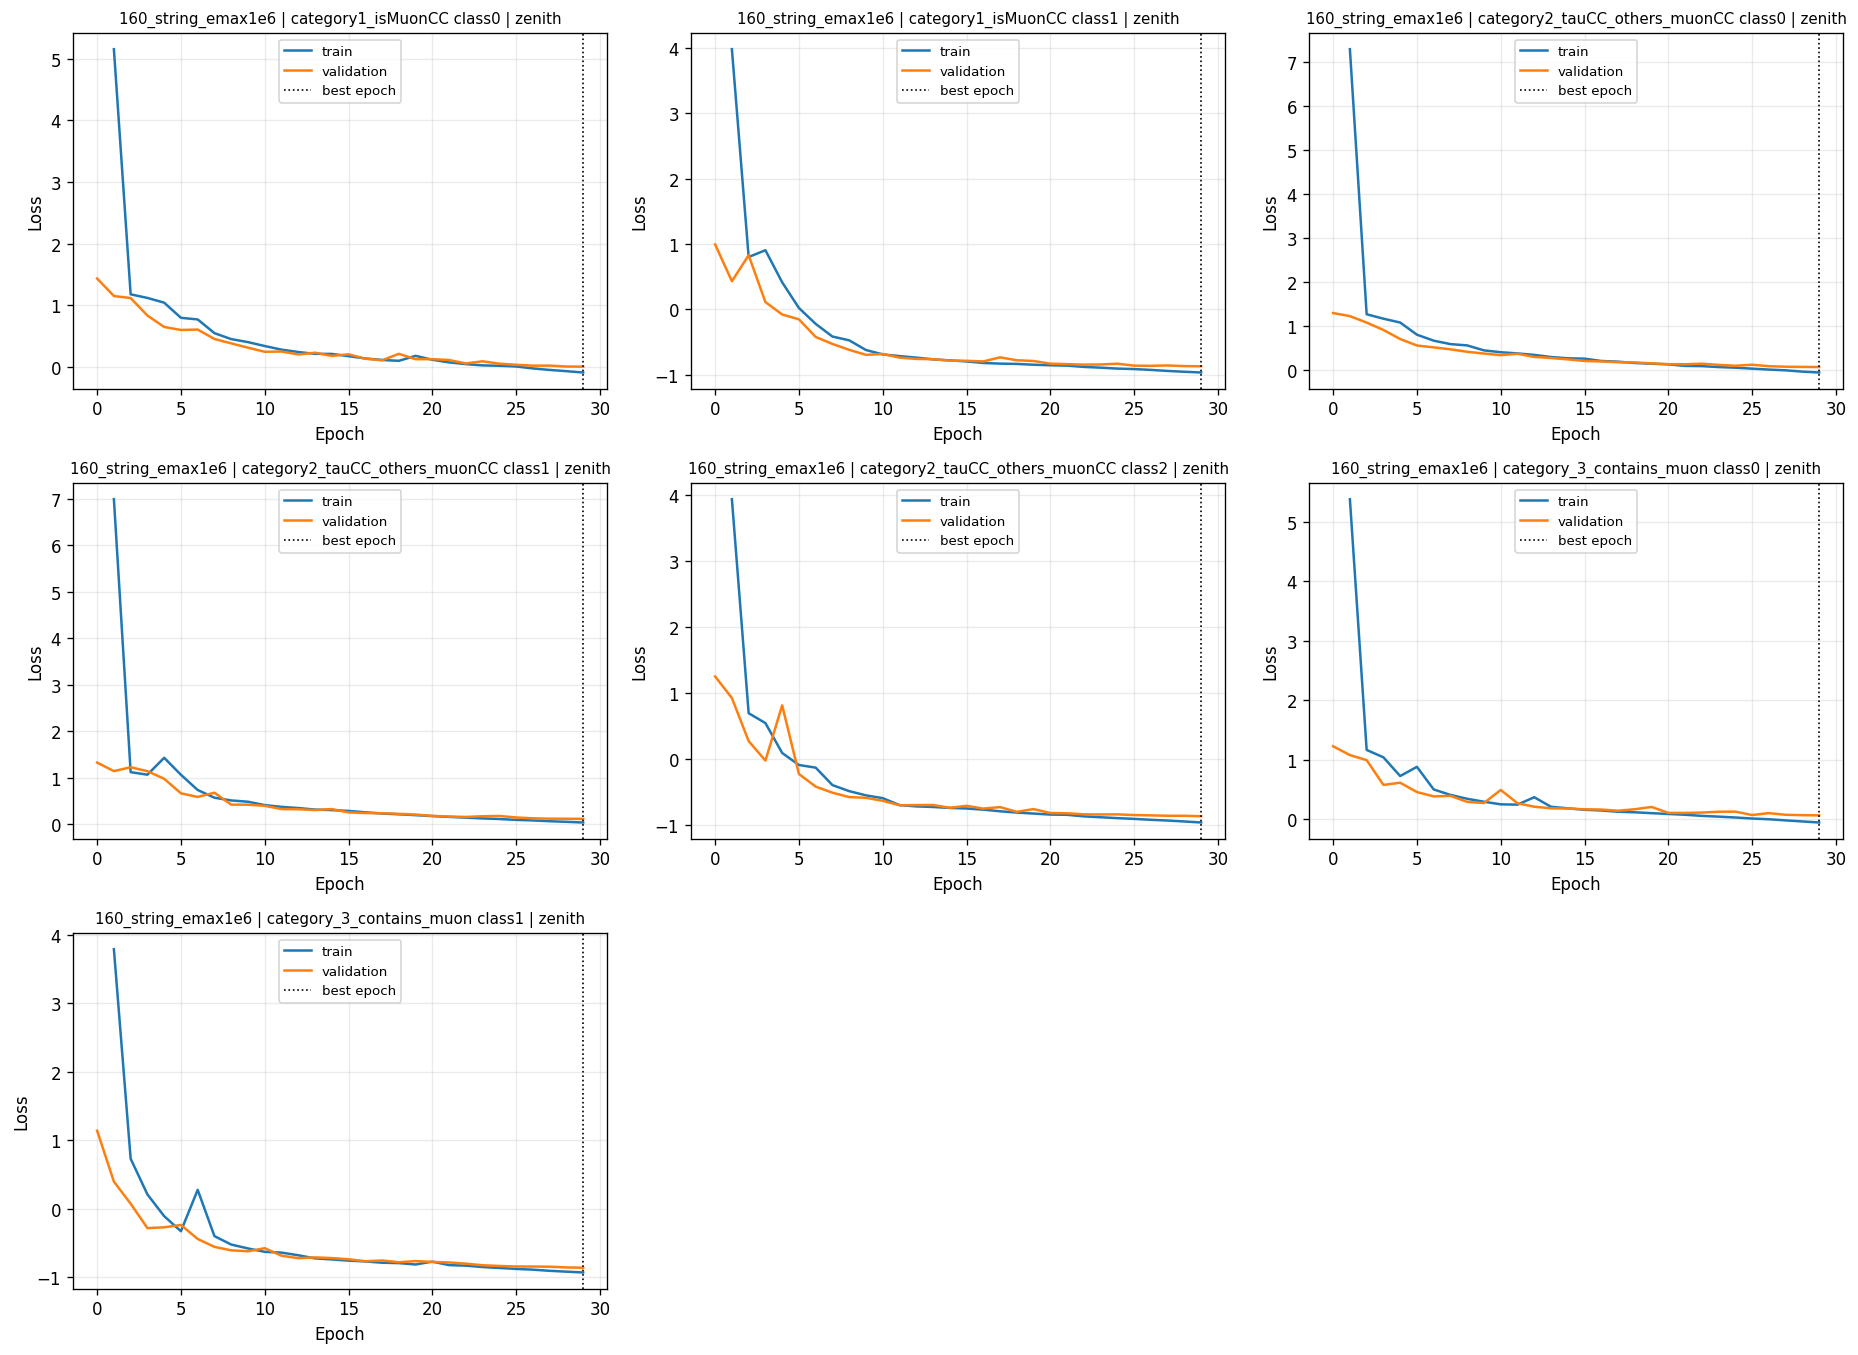

In [8]:
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="zenith")


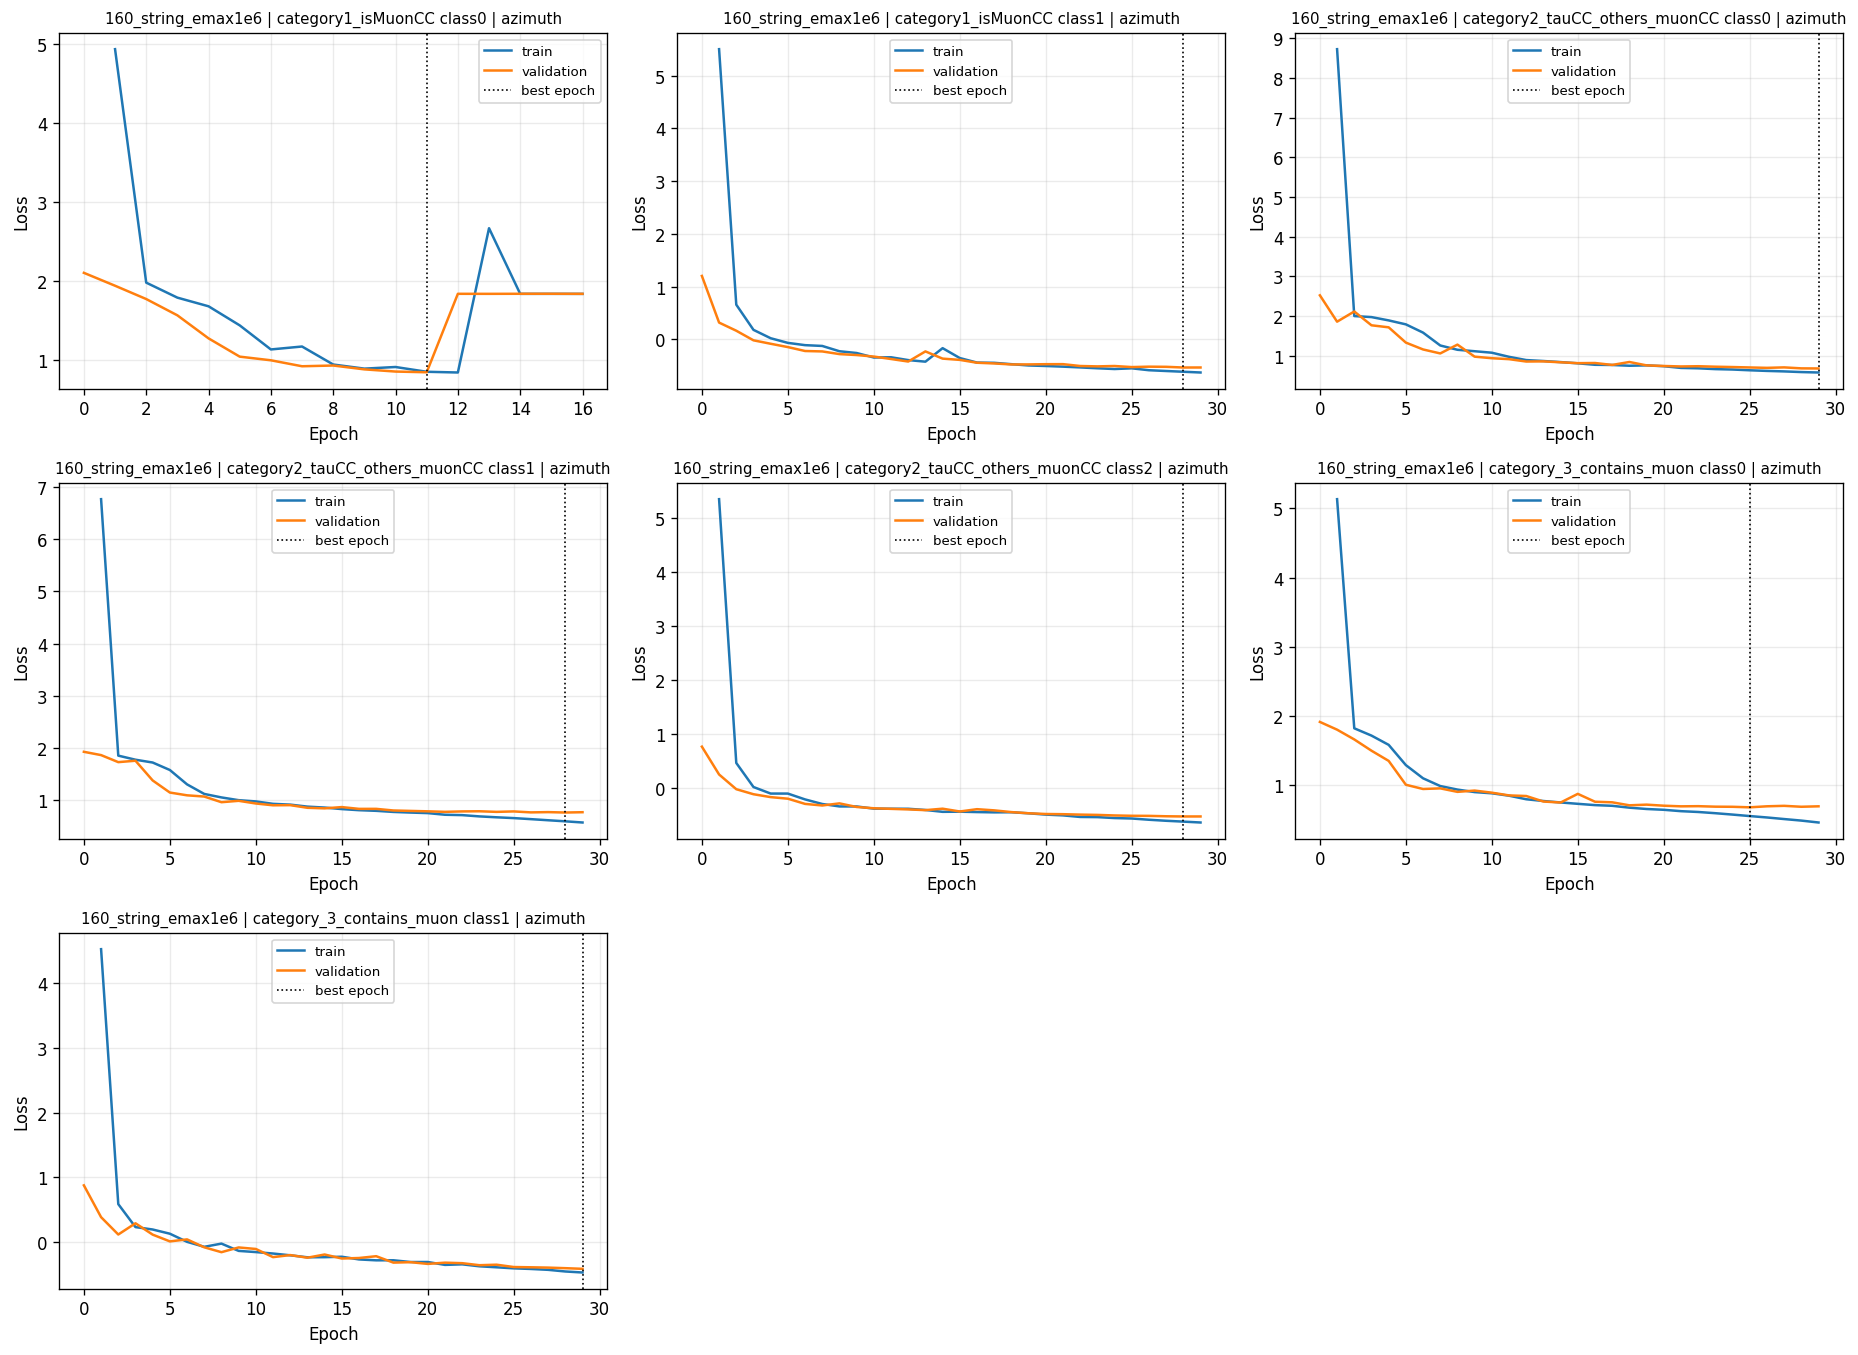

In [9]:
plot_model_histories(geometry="160_string_emax1e6", task="reconstruction", target="azimuth")


## 102-string contains-muon pipeline

This focused audit treats the classifier and its six route-specific reconstructors as one pipeline. It diagnoses whether the 30-epoch baseline budget was sufficient before defining the real hyperparameter search. Negative `val_change_last_5` means validation loss was still improving over the final five epochs.

In [10]:
FOCUS_GEOMETRY = "102_string_emax1e6"
FOCUS_CATEGORY = "category_3_contains_muon"

focus = filter_audit(
    geometry=FOCUS_GEOMETRY,
    category=FOCUS_CATEGORY,
    experiment="baseline",
).copy()

diagnostics = []
for row in focus.itertuples(index=False):
    history = histories[row.log_path].sort_values("epoch").reset_index(drop=True)
    last_window = min(5, len(history) - 1)
    val_change_last_5 = (
        history["val_loss"].iloc[-1] - history["val_loss"].iloc[-1 - last_window]
        if last_window > 0 else np.nan
    )
    train_val_gap = (
        history["val_loss"].iloc[-1] - history["train_loss"].iloc[-1]
        if "train_loss" in history and pd.notna(history["train_loss"].iloc[-1]) else np.nan
    )
    epochs_since_best = int(row.last_epoch - row.best_epoch)

    if row.reached_epoch_ceiling and row.best_epoch >= row.last_epoch - 2:
        diagnosis = "epoch budget likely too short"
    elif row.reached_epoch_ceiling:
        diagnosis = "reached ceiling after earlier best"
    else:
        diagnosis = "early stopped after plateau"

    diagnostics.append({
        "task": row.task,
        "route_class": row.route_class,
        "target": row.target,
        "epochs_ran": int(row.epochs_ran),
        "best_epoch": int(row.best_epoch),
        "best_val_loss": row.best_val_loss,
        "last_val_loss": row.last_val_loss,
        "epochs_since_best": epochs_since_best,
        "val_change_last_5": val_change_last_5,
        "last_train_val_gap": train_val_gap,
        "diagnosis": diagnosis,
    })

contains_muon_diagnostics = pd.DataFrame(diagnostics).sort_values(
    ["task", "route_class", "target"], na_position="first"
).reset_index(drop=True)
display(contains_muon_diagnostics)

,task,route_class,target,epochs_ran,best_epoch,best_val_loss,last_val_loss,epochs_since_best,val_change_last_5,last_train_val_gap,diagnosis
0,classification,NaN,classification,30,27,0.231363,0.232698,2,0.000901,0.024930,epoch budget likely too short
1,reconstruction,0.0,azimuth,30,29,1.031730,1.031730,0,-0.037447,0.087352,epoch budget likely too short
2,reconstruction,0.0,energy,30,29,0.036712,0.036712,0,-0.000470,0.004303,epoch budget likely too short
3,reconstruction,0.0,zenith,30,29,0.145364,0.145364,0,-0.018703,0.087970,epoch budget likely too short
4,reconstruction,1.0,azimuth,17,11,-0.169770,-0.152421,5,0.017349,0.044327,early stopped after plateau
5,reconstruction,1.0,energy,30,25,0.069233,0.069694,4,-0.002222,0.016493,reached ceiling after earlier best
6,reconstruction,1.0,zenith,30,29,-0.768508,-0.768508,0,-0.038464,0.055569,epoch budget likely too short


### Focused learning curves

The classifier is shown first. Reconstruction plots then compare class 0 and class 1 separately for each target.

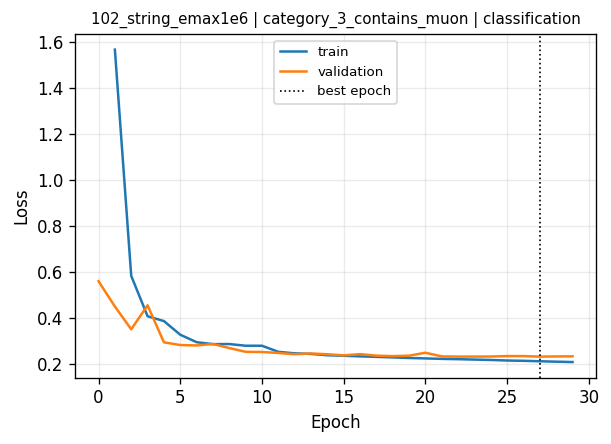

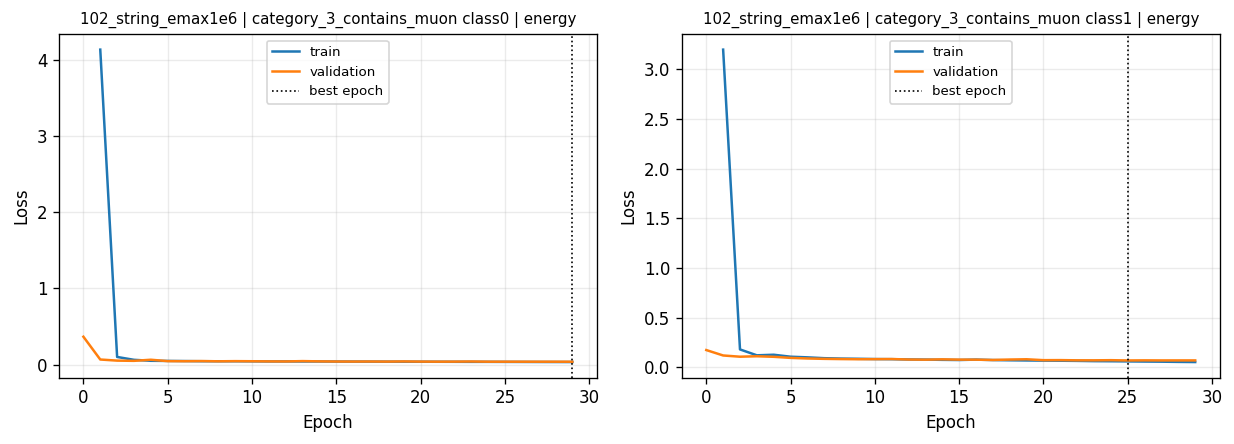

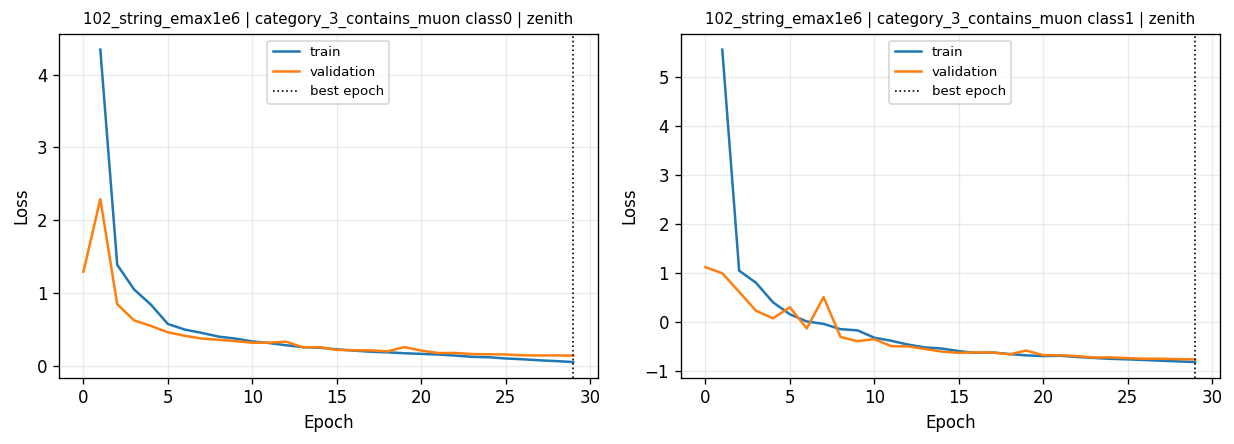

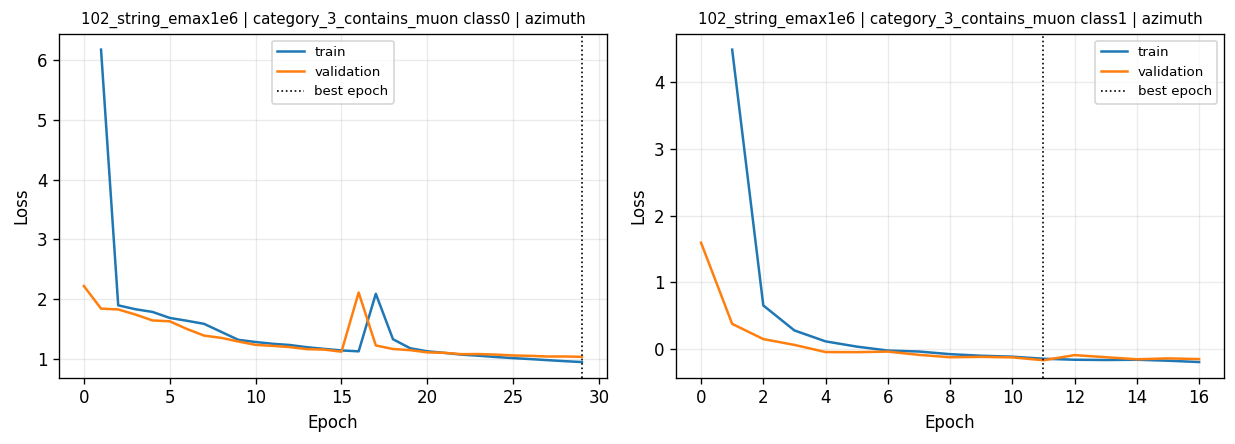

In [11]:
plot_model_histories(
    geometry=FOCUS_GEOMETRY,
    task="classification",
    category=FOCUS_CATEGORY,
    experiment="baseline",
)

for target in ["energy", "zenith", "azimuth"]:
    plot_model_histories(
        geometry=FOCUS_GEOMETRY,
        task="reconstruction",
        category=FOCUS_CATEGORY,
        target=target,
        experiment="baseline",
    )

### Baseline conclusion

The baseline histories show that the classifier and several reconstructors reach the 30-epoch ceiling while still achieving their best validation loss near the end. The real tuning runs should therefore use a fixed `max_epochs=60` and `early_stopping_patience=8` for every trial. These are training-budget controls, not Optuna search dimensions.

Classification and reconstruction should be tuned as separate stages. Reconstruction should use one study per target, with the same sampled parameters applied to both route classes. Final pipeline selection must be based on routed validation performance rather than training loss alone.